##### ARTI 560 - Computer Vision

## Motion Estimation (Optical Flow)

### Objective

In this exercise, you will use several optical flow algorithms for motion estimation.

You will follow these steps:
1. Navigate to the **Optical-Flow-in-OpenCV** folder

    `cd "Optical-Flow-in-OpenCV"`

2. Create a new **virtual environment**:

    ```
    conda create --name optical-flow python=3.7
    conda activate optical-flow
    ```
3. Install the required libraries:
    `pip install -r requirements.txt`

4. Run each of the specified optical flow algorithms and document the results with clear screenshots.

    - `python demo.py --algorithm lucaskanade --video_path videos/crowd.mp4`
    - `python demo.py --algorithm lucaskanade_dense --video_path videos/crowd.mp4`
    - `python demo.py --algorithm farneback --video_path videos/crowd.mp4`
    - `python demo.py --algorithm rlof --video_path videos/crowd.mp4`
    
    **For each algorithm:**
    - Run the algorithm using the appropriate command.
    - Keep the terminal (or Anaconda Prompt) visible, showing the exact command used.
    - Ensure the output video or visualization window is displayed.
    - Take a screenshot that clearly includes:
        - The executed command
        - The resulting output (video/frame/visualization)
    - Name each file clearly with the algorithm name, e.g.:
        - LucasKanade.png
        - Farneback.png
        - RAFT.png

5. Add all screenshots to the `results` folder located inside the Optical-Flow-in-OpenCV directory




---
## Step 1: Install Required Libraries

In [6]:
!pip install numpy opencv-python opencv-contrib-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   -----------------

  You can safely remove it manually.
  You can safely remove it manually.


## Step 2: Navigate to the Optical-Flow-in-OpenCV Folder

## Step 3: Verify Setup

In [9]:
import cv2
import numpy as np

print('OpenCV version:', cv2.__version__)
print('NumPy version:', np.__version__)
print('cv2.optflow available:', hasattr(cv2, 'optflow'))
print('Videos:', os.listdir('videos'))
print('Algorithms:', [f for f in os.listdir('algorithms') if f.endswith('.py')])

OpenCV version: 4.13.0
NumPy version: 2.2.6
cv2.optflow available: True
Videos: ['car.mp4', 'crowd.mp4']
Algorithms: ['dense_optical_flow.py', 'lucas_kanade.py']


## Step 4: Create Results Folder

In [10]:
os.makedirs('results', exist_ok=True)
print('results/ folder ready.')

results/ folder ready.


---
---
# Algorithm 1: Lucas-Kanade (Sparse Optical Flow)

**Type:** Sparse (tracks selected feature points only, not every pixel)

### How it works:
1. Detects strong corner features in the first frame using the **Shi-Tomasi** corner detector (`cv2.goodFeaturesToTrack`)
2. Tracks those corners across consecutive frames using **Pyramidal Lucas-Kanade** (`cv2.calcOpticalFlowPyrLK`)
3. Draws colored lines showing the motion trail of each tracked point

### Key Parameters:
| Parameter | Value | Meaning |
|---|---|---|
| `maxCorners` | 100 | Maximum number of corner points to detect |
| `qualityLevel` | 0.3 | Minimum accepted quality of corners (0 to 1) |
| `minDistance` | 7 | Minimum pixel distance between detected corners |
| `winSize` | (15, 15) | Search window size at each pyramid level |
| `maxLevel` | 2 | Number of pyramid levels (0 = no pyramid) |

### Math:
Based on the **brightness constancy** assumption:

$$I_x u + I_y v + I_t = 0$$

Lucas-Kanade assumes all pixels in a **local window** share the same flow, creating an overdetermined system solved by **least squares**:

$$\begin{bmatrix} u \\ v \end{bmatrix} = (A^T A)^{-1} A^T b$$

### Run via command line

In [11]:
!python demo.py --algorithm lucaskanade --video_path videos/crowd.mp4

**Expected output:** A window named "frame" showing colored dots on tracked feature points and colored lines showing motion trails. Press **ESC** to close. Press **C** to clear trails.

### Generate and Save Screenshot

In [12]:
import cv2
import numpy as np

cap = cv2.VideoCapture('videos/crowd.mp4')

# Shi-Tomasi corner detection parameters
feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)

# Lucas-Kanade optical flow parameters
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03),
)

# Random colors for drawing each tracked point
color = np.random.randint(0, 255, (100, 3))

# Read first frame and detect corners
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

# Blank mask for drawing motion trails
mask = np.zeros_like(old_frame)

# Track for 30 frames to build visible motion trails
for _ in range(30):
    ret, frame = cap.read()
    if not ret:
        break
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Calculate optical flow between old and new frame
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
    if p1 is None or st is None:
        break

    # Keep only successfully tracked points
    good_new = p1[st == 1]
    good_old = p0[st == 1]

    # Draw lines (old->new) and circles (current position)
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = np.round(new.ravel()).astype(int)
        c, d = np.round(old.ravel()).astype(int)
        mask = cv2.line(mask, (a, b), (c, d), color[i].tolist(), 2)
        frame = cv2.circle(frame, (a, b), 5, color[i].tolist(), -1)

    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)

# Overlay trails on frame and save
img = cv2.add(frame, mask)
cv2.imwrite('results/LucasKanade.png', img)
cap.release()
print('Saved: results/LucasKanade.png')

Saved: results/LucasKanade.png


### Display Result

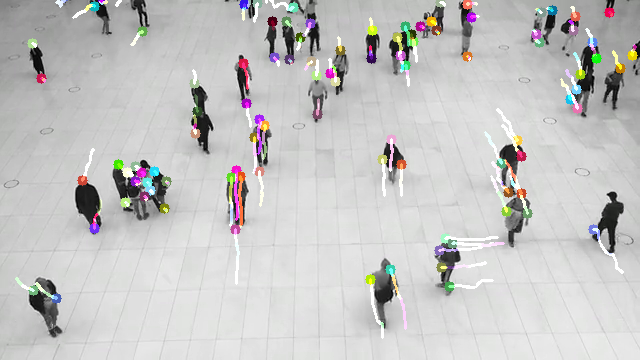

In [13]:
from IPython.display import Image, display
display(Image(filename='results/LucasKanade.png'))

---
---
# Algorithm 2: Dense Lucas-Kanade (Dense Optical Flow)

**Type:** Dense (computes flow for every pixel)

### How it works:
1. Computes sparse optical flow at detected feature points
2. **Interpolates** between those sparse matches to produce flow for **every pixel**

OpenCV function: `cv2.optflow.calcOpticalFlowSparseToDense`

### HSV Visualization:
Dense flow is visualized using the HSV color space:

| Channel | Encodes | Meaning |
|---|---|---|
| **Hue** | `angle = atan2(dy, dx)` | Direction of motion (color) |
| **Saturation** | Fixed at 255 | Always full color |
| **Value** | `magnitude = sqrt(dx² + dy²)` | Speed of motion (brightness) |

**Color meanings:** Red = rightward, Green = downward, Blue/Cyan = leftward, Yellow = upward. Bright = fast, Dark = slow/none.

### Run via command line

In [14]:
!python demo.py --algorithm lucaskanade_dense --video_path videos/crowd.mp4

**Expected output:** Two windows - "frame" (original video) and "optical flow" (dense flow color map). Press **ESC** to close.

### Generate and Save Screenshot

In [15]:
import cv2
import numpy as np

cap = cv2.VideoCapture('videos/crowd.mp4')
ret, old_frame = cap.read()

# HSV template for visualization
hsv = np.zeros_like(old_frame)
hsv[..., 1] = 255  # Full saturation

old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# Process 30 frames
for _ in range(30):
    ret, new_frame = cap.read()
    if not ret:
        break
    frame_copy = new_frame.copy()
    new_gray = cv2.cvtColor(new_frame, cv2.COLOR_BGR2GRAY)

    # Dense Lucas-Kanade: SparseToDense interpolation
    flow = cv2.optflow.calcOpticalFlowSparseToDense(old_gray, new_gray, None)

    # Convert flow (dx, dy) to polar (magnitude, angle)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2       # Hue = direction
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)  # Value = speed
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    old_gray = new_gray

# Save: original frame + flow side by side
combined = np.hstack([frame_copy, bgr])
cv2.imwrite('results/LucasKanade_Dense.png', combined)
cap.release()
print('Saved: results/LucasKanade_Dense.png')

Saved: results/LucasKanade_Dense.png


### Display Result

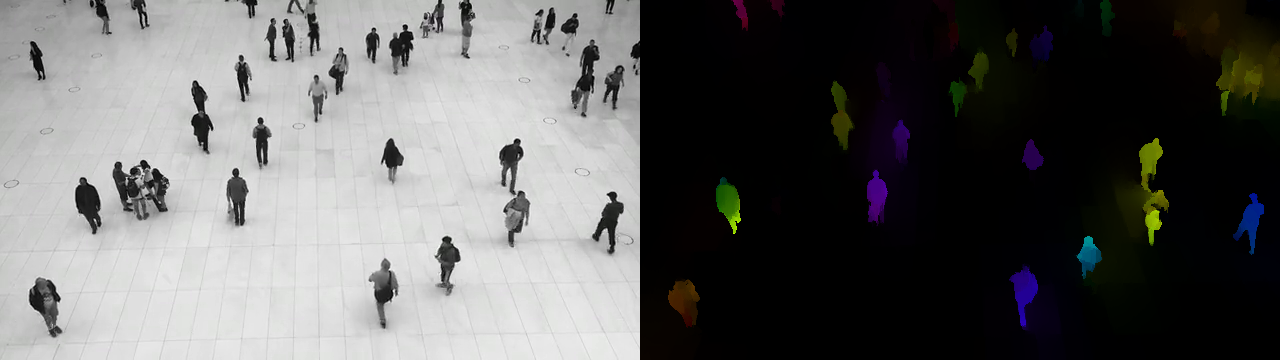

In [16]:
from IPython.display import Image, display
display(Image(filename='results/LucasKanade_Dense.png'))

---
---
# Algorithm 3: Farneback (Dense Optical Flow)

**Type:** Dense (computes flow for every pixel)

### How it works:
Approximates each pixel's neighborhood with a **quadratic polynomial**:

$$f(x) \approx x^T A x + b^T x + c$$

By analyzing how the polynomial coefficients change between frames, displacement is estimated for every pixel.

### Parameters:
| Parameter | Value | Meaning |
|---|---|---|
| `pyr_scale` | 0.5 | Each pyramid level is half the previous size |
| `levels` | 3 | Number of pyramid layers |
| `winsize` | 15 | Averaging window size (larger = smoother, less noise) |
| `iterations` | 3 | Iterations at each pyramid level |
| `poly_n` | 5 | Pixel neighborhood size for polynomial expansion |
| `poly_sigma` | 1.2 | Gaussian sigma for smoothing derivatives |
| `flags` | 0 | No special flags |

### Run via command line

In [17]:
!python demo.py --algorithm farneback --video_path videos/crowd.mp4

**Expected output:** Two windows - "frame" (original video) and "optical flow" (color-coded dense flow). Press **ESC** to close.

### Generate and Save Screenshot

In [18]:
import cv2
import numpy as np

cap = cv2.VideoCapture('videos/crowd.mp4')
ret, old_frame = cap.read()

hsv = np.zeros_like(old_frame)
hsv[..., 1] = 255

old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# Process 30 frames
for _ in range(30):
    ret, new_frame = cap.read()
    if not ret:
        break
    frame_copy = new_frame.copy()
    new_gray = cv2.cvtColor(new_frame, cv2.COLOR_BGR2GRAY)

    # Farneback dense optical flow
    flow = cv2.calcOpticalFlowFarneback(
        old_gray, new_gray, None,
        0.5,   # pyr_scale
        3,     # levels
        15,    # winsize
        3,     # iterations
        5,     # poly_n
        1.2,   # poly_sigma
        0      # flags
    )

    # Convert to polar and encode as HSV
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    old_gray = new_gray

# Save: original frame + flow side by side
combined = np.hstack([frame_copy, bgr])
cv2.imwrite('results/Farneback.png', combined)
cap.release()
print('Saved: results/Farneback.png')

Saved: results/Farneback.png


### Display Result

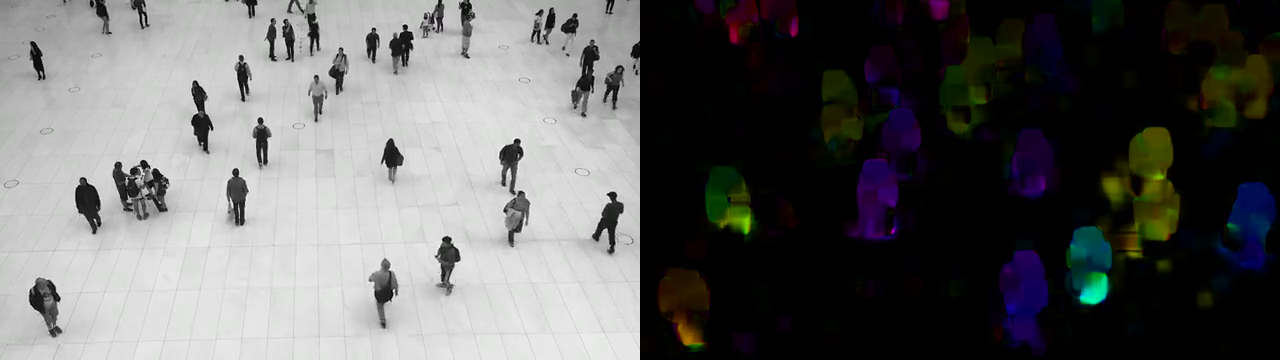

In [19]:
from IPython.display import Image, display
display(Image(filename='results/Farneback.png'))

---
---
# Algorithm 4: RLOF (Robust Local Optical Flow)

**Type:** Dense (computes flow for every pixel)

### How it works:
RLOF extends Lucas-Kanade with three key improvements:
- **Robust estimation** to handle outliers and partial occlusions
- **Illumination model** to handle lighting changes between frames
- Works on **color (BGR) frames** directly (not grayscale) for better accuracy

OpenCV function: `cv2.optflow.calcOpticalFlowDenseRLOF`

**Key difference from Farneback:** RLOF is more robust to illumination changes and occlusions, but slower.

### Run via command line

In [20]:
!python demo.py --algorithm rlof --video_path videos/crowd.mp4

**Expected output:** Two windows - "frame" (original video) and "optical flow" (color-coded dense flow). Press **ESC** to close.

### Generate and Save Screenshot

In [21]:
import cv2
import numpy as np

cap = cv2.VideoCapture('videos/crowd.mp4')
ret, old_frame = cap.read()

hsv = np.zeros_like(old_frame)
hsv[..., 1] = 255

# RLOF works on COLOR frames (no grayscale conversion)
old_proc = old_frame.copy()

# Process 30 frames
for _ in range(30):
    ret, new_frame = cap.read()
    if not ret:
        break
    frame_copy = new_frame.copy()
    new_proc = new_frame.copy()

    # RLOF dense optical flow (color input)
    flow = cv2.optflow.calcOpticalFlowDenseRLOF(old_proc, new_proc, None)

    # Convert to polar and encode as HSV
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    old_proc = new_proc

# Save: original frame + flow side by side
combined = np.hstack([frame_copy, bgr])
cv2.imwrite('results/RLOF.png', combined)
cap.release()
print('Saved: results/RLOF.png')

Saved: results/RLOF.png


### Display Result

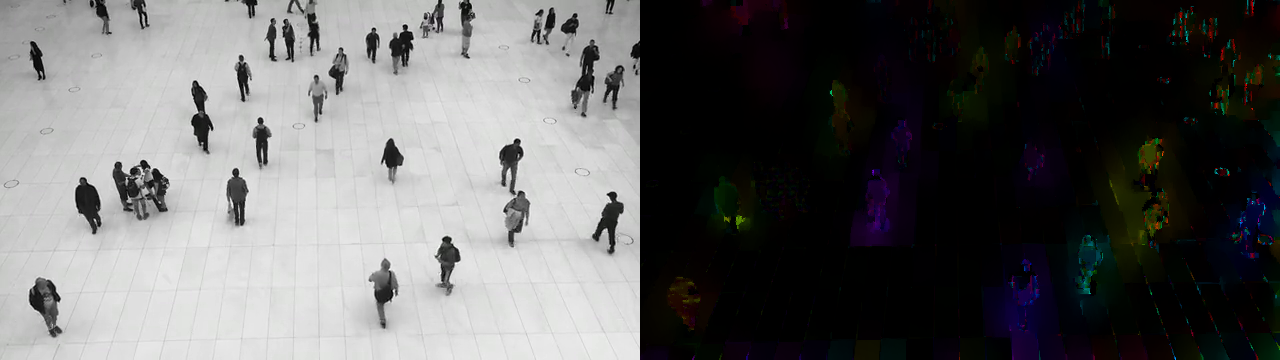

In [22]:
from IPython.display import Image, display
display(Image(filename='results/RLOF.png'))

---
---
# Algorithm 5: RAFT (Deep Learning Optical Flow)

**Type:** Dense (deep learning-based, state-of-the-art)

### How RAFT works:
1. **Feature Extraction** - a CNN extracts features from both frames
2. **Correlation Volume** - computes all-pairs correlation between features of frame 1 and frame 2
3. **Recurrent Refinement** - a GRU (Gated Recurrent Unit) iteratively refines the flow over 12 iterations
4. Outputs `flow_low` (low-resolution) and `flow_up` (full-resolution upsampled flow)

The pretrained model `raft-sintel.pth` was trained on the MPI Sintel dataset.

### Install RAFT Dependencies

In [27]:
!pip install "numpy" "opencv-python" "scipy" "torch" "torchvision"

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   -------

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'A:\\envs\\tf210\\Lib\\site-packages\\distutils-precedence.pth'
Consider using the `--user` option or check the permissions.



   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.5 MB 68.7 kB/s eta 0:06:36
   ------------ --------------------------- 12.3/39.

### Clone the RAFT Core Repository

In [28]:
import os
os.chdir('../Optical-Flow-Estimation-using-Deep-Learning-RAFT')
print('Current directory:', os.getcwd())

Current directory: c:\Users\lenovo\Desktop\Alhnouf CV\arti560-computer-vision-labs\lab06-motion-estimation\Optical-Flow-Estimation-using-Deep-Learning-RAFT


In [29]:
!git clone https://github.com/princeton-vl/RAFT.git

fatal: destination path 'RAFT' already exists and is not an empty directory.


### Run RAFT via command line

In [30]:
!python inference.py --model=./models/raft-sintel.pth --video ./videos/crowd.mp4

Traceback (most recent call last):
  File "c:\Users\lenovo\Desktop\Alhnouf CV\arti560-computer-vision-labs\lab06-motion-estimation\Optical-Flow-Estimation-using-Deep-Learning-RAFT\inference.py", line 10, in <module>
    import torch
ModuleNotFoundError: No module named 'torch'


**Expected output:** A window named "Optical Flow" showing the original frame on top and dense flow visualization on the bottom. Press **ESC** to close.

### Generate and Save Screenshot

---
---
# Verification: Check All Results

In [34]:
import os

results_dir = '../Optical-Flow-in-OpenCV/results'
expected = ['LucasKanade.png', 'LucasKanade_Dense.png', 'Farneback.png', 'RLOF.png', 'RAFT.png']

print('=== Results Folder ===')
files = os.listdir(results_dir)
for f in files:
    if f == '.gitkeep':
        continue
    size = os.path.getsize(os.path.join(results_dir, f))
    print(f'  {f} ({size:,} bytes)')

print('\n=== Checklist ===')
for name in expected:
    status = 'FOUND' if name in files else 'MISSING'
    print(f'  [{status}] {name}')

=== Results Folder ===
  Farneback.png (436,694 bytes)
  LucasKanade.png (287,856 bytes)
  LucasKanade_Dense.png (369,372 bytes)
  RLOF.png (450,957 bytes)

=== Checklist ===
  [FOUND] LucasKanade.png
  [FOUND] LucasKanade_Dense.png
  [FOUND] Farneback.png
  [FOUND] RLOF.png
  [MISSING] RAFT.png


---
---
# Algorithm Comparison

| Feature | Lucas-Kanade (Sparse) | Dense Lucas-Kanade | Farneback | RLOF | RAFT |
|---|---|---|---|---|---|
| **Type** | Sparse | Dense | Dense | Dense | Dense |
| **Input** | Grayscale | Grayscale | Grayscale | Color (BGR) | Color (RGB) |
| **Speed** | Very Fast | Moderate | Fast | Slow | Slowest (GPU recommended) |
| **Accuracy** | Good for corners | Moderate | Good | Very Good | State-of-the-art |
| **Large Motion** | Poor (pyramids help) | Moderate | Moderate | Good | Excellent |
| **Illumination Robustness** | Low | Low | Low | High | High |
| **Occlusion Handling** | None | Basic | Basic | Good | Good |
| **GPU Required** | No | No | No | No | Recommended |
| **Method** | Feature tracking | Sparse-to-Dense interpolation | Polynomial expansion | Robust local estimation | Neural network (recurrent GRU) |
| **OpenCV Function** | `calcOpticalFlowPyrLK` | `calcOpticalFlowSparseToDense` | `calcOpticalFlowFarneback` | `calcOpticalFlowDenseRLOF` | RAFT model (PyTorch) |

---
# Theoretical Background

### What is Optical Flow?
Optical flow is the pattern of apparent motion of objects in a visual scene caused by relative motion between the camera and the scene. It is represented as a **2D vector field** where each vector shows the displacement of a pixel from one frame to the next.

### The Optical Flow Constraint Equation
The fundamental assumption is **brightness constancy** - a pixel's intensity does not change between frames:

$$I(x, y, t) = I(x + dx, y + dy, t + dt)$$

Using Taylor expansion:

$$I_x u + I_y v + I_t = 0$$

This is **1 equation with 2 unknowns** (the **aperture problem**). Each method resolves this differently:

| Method | How it resolves the aperture problem |
|---|---|
| **Lucas-Kanade** | All pixels in a local window share the same flow (overdetermined least squares) |
| **Farneback** | Neighborhood approximated by a quadratic polynomial |
| **RLOF** | Robust estimation + illumination model on color frames |
| **RAFT** | Learned features + correlation volume + recurrent GRU refinement |